# BoomBikes Bike Sharing - Multiple Linear Regression

## Problem
BoomBikes is a US bike sharing company. Their revenue dropped during the COVID-19
lockdown and they want to be ready when the market opens up again. They asked us
to figure out which factors actually drive daily bike rental demand and build a
model that explains it.

So in this notebook I am trying to:

1. Find the variables that significantly affect daily rentals (`cnt`).
2. See how well those variables explain the demand using R-squared.
3. Build a multiple linear regression model that is easy to interpret so the
   business team can act on it.

## My approach
I followed the usual steps we learnt in class:

1. Load the data, look at it, drop columns that are not useful.
2. Convert the numeric coded categorical columns (season, weathersit, etc.) to
   string labels so dummy variables make sense later.
3. EDA - pair plots, correlation heatmap, box plots for categorical vs cnt.
4. Create dummies with `drop_first=True`, do a 70-30 train test split.
5. Scale the numerical features using MinMaxScaler (fit on train only).
6. Use RFE to shortlist 15 features, then refine using p-values and VIF.
7. Residual analysis to check the regression assumptions.
8. Predict on the test set and compute R-squared.

In [1]:
# 1. Imports
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set(style="whitegrid")
%matplotlib inline
np.random.seed(42)


Matplotlib is building the font cache; this may take a moment.


## 2. Loading the data and a quick look

In [2]:
df = pd.read_csv("day.csv")
print("Shape:", df.shape)
df.head()

Shape: (730, 16)


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2018,1,0,1,0,6,0,2,14.110847,18.18125,80.5833,10.749882,331,654,985
1,2,02-01-2018,1,0,1,0,0,0,2,14.902598,17.68695,69.6087,16.652113,131,670,801
2,3,03-01-2018,1,0,1,0,1,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,4,04-01-2018,1,0,1,0,2,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,5,05-01-2018,1,0,1,0,3,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     730 non-null    int64  
 1   dteday      730 non-null    str    
 2   season      730 non-null    int64  
 3   yr          730 non-null    int64  
 4   mnth        730 non-null    int64  
 5   holiday     730 non-null    int64  
 6   weekday     730 non-null    int64  
 7   workingday  730 non-null    int64  
 8   weathersit  730 non-null    int64  
 9   temp        730 non-null    float64
 10  atemp       730 non-null    float64
 11  hum         730 non-null    float64
 12  windspeed   730 non-null    float64
 13  casual      730 non-null    int64  
 14  registered  730 non-null    int64  
 15  cnt         730 non-null    int64  
dtypes: float64(4), int64(11), str(1)
memory usage: 91.4 KB


In [4]:
df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000
mean,365.500000,2.498630,0.500000,6.526027,0.028767,2.997260,0.683562,1.394521,20.319259,23.726322,62.765175,12.763620,849.249315,3658.757534,4508.006849
std,210.877136,1.110184,0.500343,3.450215,0.167266,2.006161,0.465405,0.544807,7.506729,8.150308,14.237589,5.195841,686.479875,1559.758728,1936.011647
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.424346,3.953480,0.000000,1.500244,2.000000,20.000000,22.000000
25%,183.250000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,13.811885,16.889713,52.000000,9.041650,316.250000,2502.250000,3169.750000
50%,365.500000,3.000000,0.500000,7.000000,0.000000,3.000000,1.000000,1.000000,20.465826,24.368225,62.625000,12.125325,717.000000,3664.500000,4548.500000
75%,547.750000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,26.880615,30.445775,72.989575,15.625589,1096.500000,4783.250000,5966.000000
max,730.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,35.328347,42.044800,97.250000,34.000021,3410.000000,6946.000000,8714.000000


In [5]:
# Check missing values & duplicates
print("Missing values per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
 instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Duplicate rows: 0


## 3. Data Cleaning

### Columns I am dropping
- `instant` is just a row number, no information.
- `dteday` is the date, but the year, month and weekday are already there as
  separate columns so I do not need it.
- `casual` and `registered` together add up to `cnt`. If I keep them the model
  will basically just learn the sum, which is data leakage.
- `atemp` is "feels like" temperature and is almost the same as `temp`
  (correlation ~0.99). Keeping both will cause severe multicollinearity, so I
  am dropping `atemp` and keeping `temp`.

In [6]:
df = df.drop(columns=["instant", "dteday", "casual", "registered", "atemp"])
df.head()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,hum,windspeed,cnt
0,1,0,1,0,6,0,2,14.110847,80.5833,10.749882,985
1,1,0,1,0,0,0,2,14.902598,69.6087,16.652113,801
2,1,0,1,0,1,1,1,8.050924,43.7273,16.636703,1349
3,1,0,1,0,2,1,1,8.200000,59.0435,10.739832,1562
4,1,0,1,0,3,1,1,9.305237,43.6957,12.522300,1600


### Converting the coded categoricals to readable labels

In the data dictionary `season`, `mnth`, `weekday` and `weathersit` are stored
as numbers (1, 2, 3, 4 etc.) but they are not ordinal - season 4 is not
"more" than season 1. If I leave them as numbers the model will treat them as
continuous which is wrong. So I am mapping them to short string labels and
will create dummy variables later.

In [7]:
season_map  = {1: "spring", 2: "summer", 3: "fall", 4: "winter"}
weather_map = {1: "clear", 2: "mist", 3: "light_rain_snow", 4: "heavy_rain_snow"}
month_map   = {1: "jan", 2: "feb", 3: "mar", 4: "apr", 5: "may", 6: "jun",
               7: "jul", 8: "aug", 9: "sep", 10: "oct", 11: "nov", 12: "dec"}
weekday_map = {0: "sun", 1: "mon", 2: "tue", 3: "wed", 4: "thu", 5: "fri", 6: "sat"}

df["season"]     = df["season"].map(season_map)
df["weathersit"] = df["weathersit"].map(weather_map)
df["mnth"]       = df["mnth"].map(month_map)
df["weekday"]    = df["weekday"].map(weekday_map)

df.head()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,hum,windspeed,cnt
0,spring,0,jan,0,sat,0,mist,14.110847,80.5833,10.749882,985
1,spring,0,jan,0,sun,0,mist,14.902598,69.6087,16.652113,801
2,spring,0,jan,0,mon,1,clear,8.050924,43.7273,16.636703,1349
3,spring,0,jan,0,tue,1,clear,8.200000,59.0435,10.739832,1562
4,spring,0,jan,0,wed,1,clear,9.305237,43.6957,12.522300,1600


## 4. Exploratory Data Analysis

### 4.1 Numerical variables vs cnt

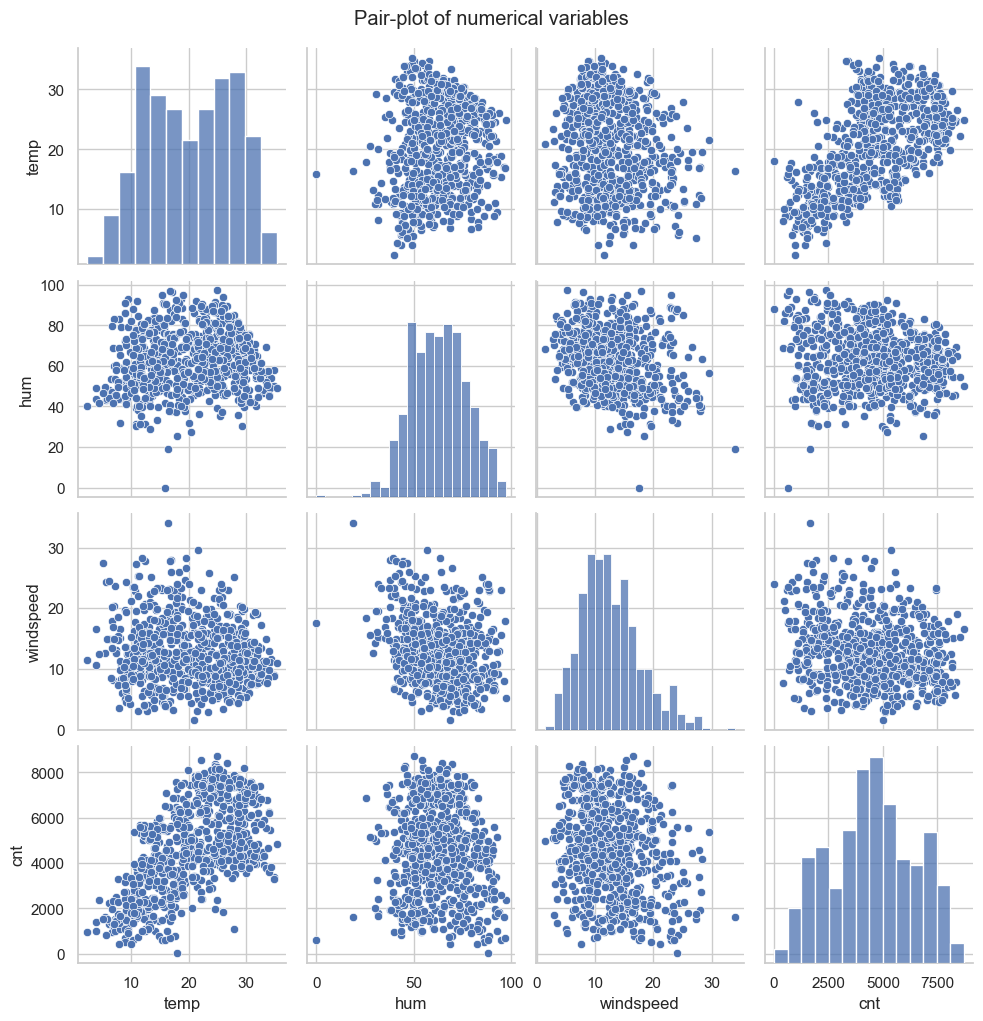

In [8]:
num_vars = ["temp", "hum", "windspeed", "cnt"]
sns.pairplot(df[num_vars])
plt.suptitle("Pair-plot of numerical variables", y=1.02)
plt.show()

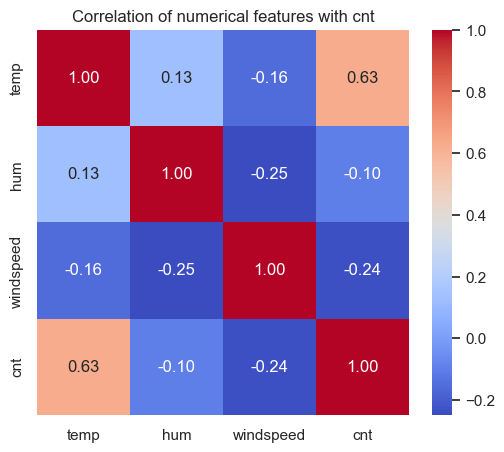

In [9]:
# Correlation heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(df[num_vars].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation of numerical features with cnt")
plt.show()

**What I see:** `temp` has the strongest positive correlation with `cnt`
(around 0.63). `hum` and `windspeed` have weaker, mostly negative correlations
with cnt.

### 4.2 Categorical variables vs cnt

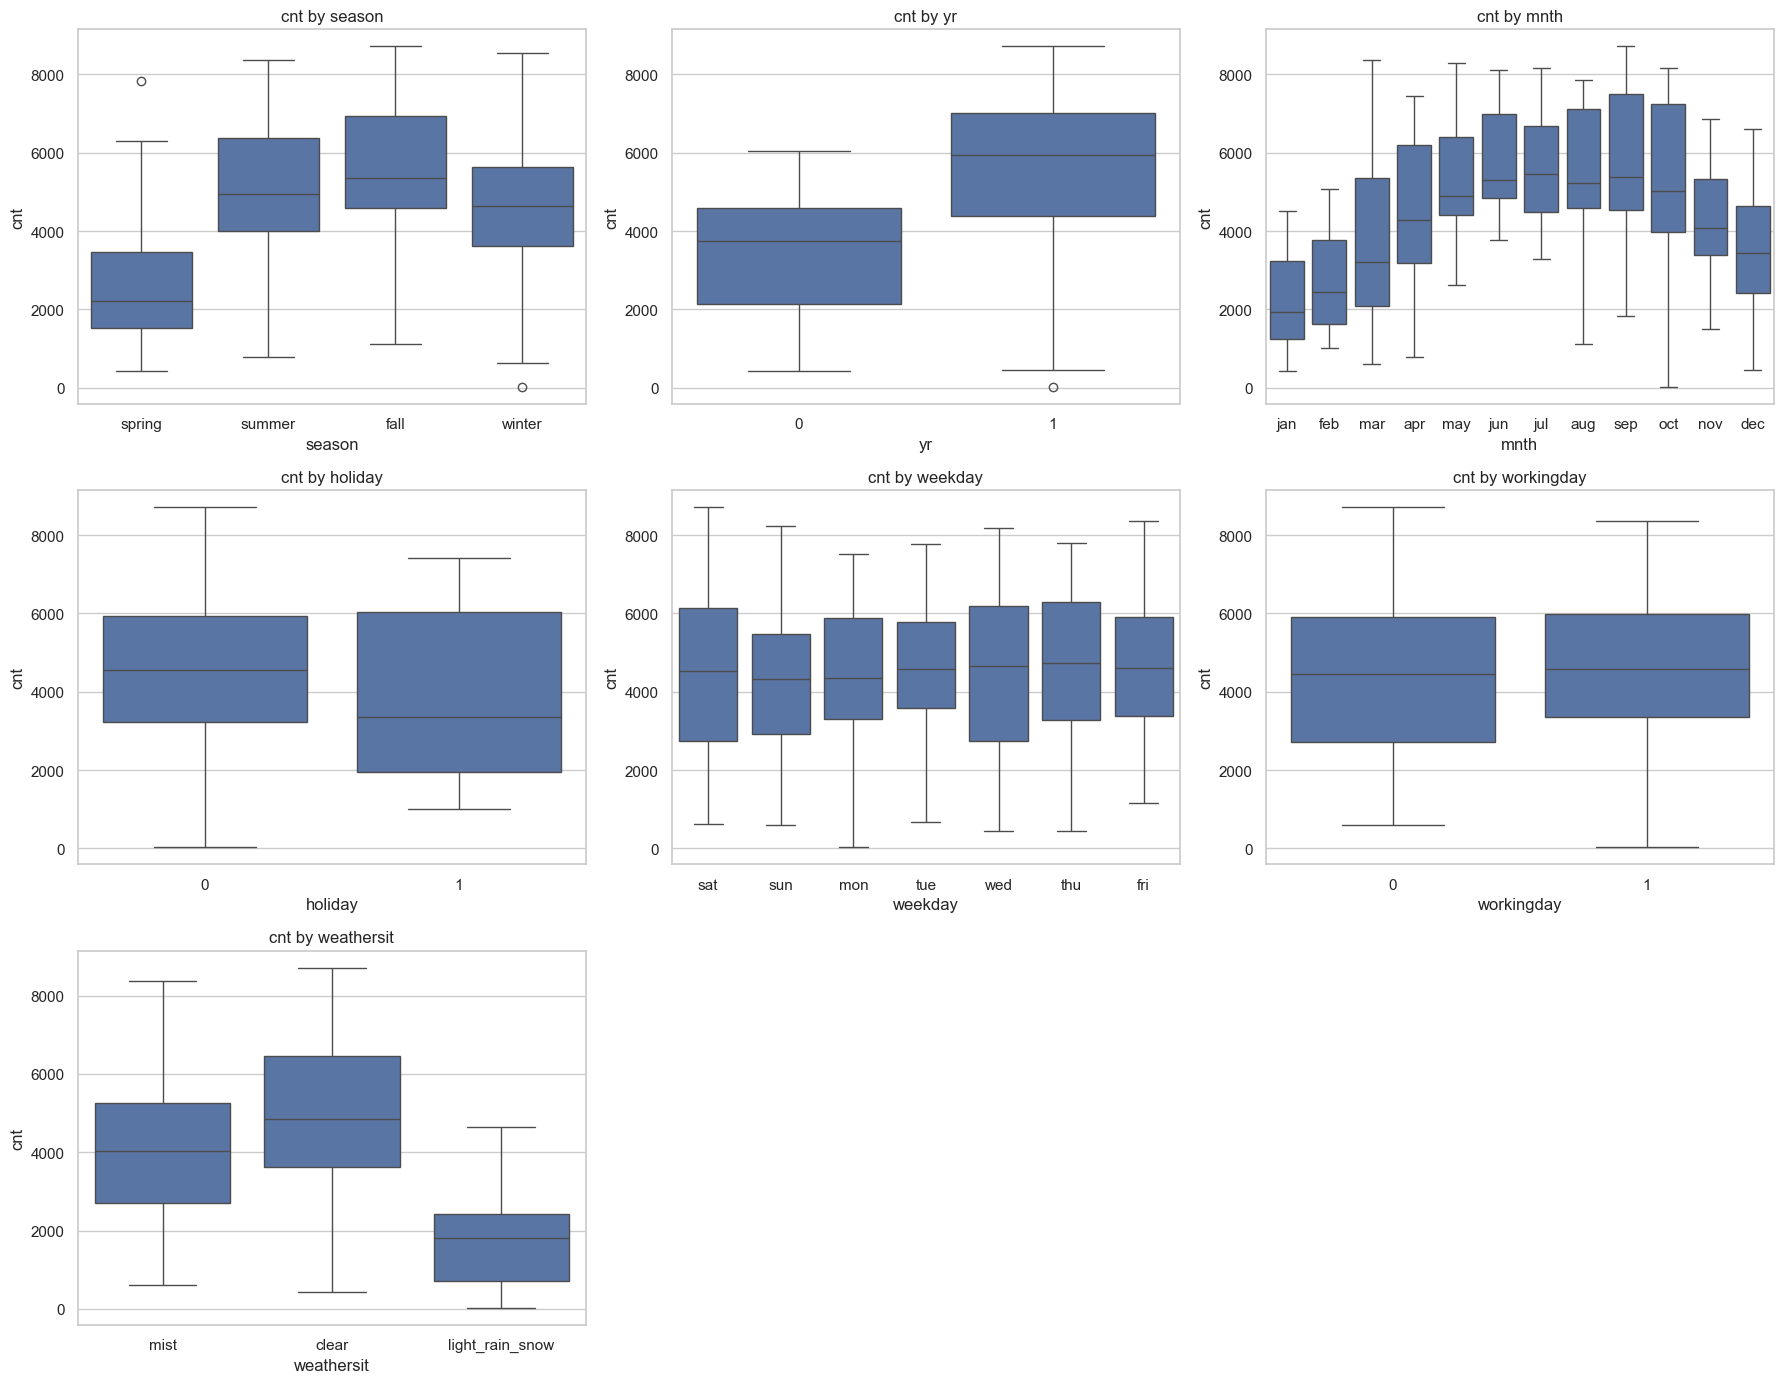

In [10]:
cat_vars = ["season", "yr", "mnth", "holiday", "weekday", "workingday", "weathersit"]
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()
for i, col in enumerate(cat_vars):
    sns.boxplot(x=col, y="cnt", data=df, ax=axes[i])
    axes[i].set_title(f"cnt by {col}")
for j in range(len(cat_vars), len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.show()

**Observations from the box plots:**

| Variable | What I noticed |
|---|---|
| `season` | Demand is highest in fall, then summer and winter, lowest in spring. |
| `yr` | 2019 has clearly higher demand than 2018, so bike sharing is growing year on year. The assignment also warned us not to drop this column and now I see why. |
| `mnth` | Demand is high from May to October and drops in Dec-Feb. Matches the season pattern. |
| `weathersit` | Demand decreases as weather gets worse: clear > mist > light rain/snow. |
| `holiday` | Demand on holidays is slightly lower than non-holidays. |
| `weekday` | Pretty similar across weekdays, Saturday a bit higher. |
| `workingday` | Working day vs non-working day medians are close, but working day has a tighter spread. |

## 5. Preparing the data for the model

### 5.1 Dummy variables with drop_first=True

When we one-hot encode a categorical with n levels we get n columns that always
sum to 1. That makes the design matrix singular (dummy variable trap) so I am
using `drop_first=True` which leaves n-1 dummies and treats the dropped level
as the baseline.

In [11]:
df_enc = pd.get_dummies(
    df,
    columns=["season", "weathersit", "mnth", "weekday"],
    drop_first=True,
    dtype=int,
)
print("Shape after encoding:", df_enc.shape)
df_enc.head()

Shape after encoding: (730, 29)


,yr,holiday,workingday,temp,hum,windspeed,cnt,season_spring,season_summer,season_winter,...,mnth_may,mnth_nov,mnth_oct,mnth_sep,weekday_mon,weekday_sat,weekday_sun,weekday_thu,weekday_tue,weekday_wed
0,0,0,0,14.110847,80.5833,10.749882,985,1,0,0,...,0,0,0,0,0,1,0,0,0,0
1,0,0,0,14.902598,69.6087,16.652113,801,1,0,0,...,0,0,0,0,0,0,1,0,0,0
2,0,0,1,8.050924,43.7273,16.636703,1349,1,0,0,...,0,0,0,0,1,0,0,0,0,0
3,0,0,1,8.200000,59.0435,10.739832,1562,1,0,0,...,0,0,0,0,0,0,0,0,1,0
4,0,0,1,9.305237,43.6957,12.522300,1600,1,0,0,...,0,0,0,0,0,0,0,0,0,1


### 5.2 Train test split (70-30)

In [12]:
df_train, df_test = train_test_split(df_enc, train_size=0.7, random_state=42)
print("Train:", df_train.shape, " | Test:", df_test.shape)

Train: (510, 29)  | Test: (220, 29)


### 5.3 Scaling the numerical columns

I am using MinMax scaling so all the numeric columns (and the target) sit in
[0, 1]. The main reason is interpretability - once everything is on the same
range, I can just compare the size of the coefficients to see which feature is
most important.

Important: I fit the scaler only on the train set and then transform the test
set, otherwise information from the test set leaks into training.

In [13]:
num_cols = ["temp", "hum", "windspeed", "cnt"]

scaler = MinMaxScaler()
df_train[num_cols] = scaler.fit_transform(df_train[num_cols])
df_test[num_cols]  = scaler.transform(df_test[num_cols])

df_train.describe()

,yr,holiday,workingday,temp,hum,windspeed,cnt,season_spring,season_summer,season_winter,...,mnth_may,mnth_nov,mnth_oct,mnth_sep,weekday_mon,weekday_sat,weekday_sun,weekday_thu,weekday_tue,weekday_wed
count,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.00000,...,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000
mean,0.519608,0.027451,0.668627,0.551313,0.654203,0.415045,0.497429,0.231373,0.258824,0.24902,...,0.092157,0.090196,0.090196,0.090196,0.149020,0.150980,0.152941,0.145098,0.131373,0.141176
std,0.500106,0.163554,0.471169,0.227237,0.143788,0.185760,0.234207,0.422124,0.438419,0.43287,...,0.289531,0.286744,0.286744,0.286744,0.356457,0.358381,0.360284,0.352545,0.338139,0.348545
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.354526,0.544033,0.281934,0.344772,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,1.000000,0.575824,0.660798,0.384737,0.501871,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,1.000000,0.745338,0.756977,0.526489,0.677080,0.000000,1.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [14]:
# Separate features and target
y_train = df_train.pop("cnt")
X_train = df_train

y_test = df_test.pop("cnt")
X_test = df_test

print("X_train:", X_train.shape, " | y_train:", y_train.shape)
print("X_test :", X_test.shape,  " | y_test :", y_test.shape)

X_train: (510, 28)  | y_train: (510,)
X_test : (220, 28)  | y_test : (220,)


## 6. Feature Selection using RFE

I have 28 features after encoding. That is too many to handle manually for OLS.
So I am using RFE with a `LinearRegression` estimator to keep the top 15
features. After that I will manually refine using p-values and VIF in
statsmodels.

In [15]:
lm = LinearRegression()
rfe = RFE(estimator=lm, n_features_to_select=15)
rfe.fit(X_train, y_train)

rfe_summary = pd.DataFrame({
    "Feature": X_train.columns,
    "Selected": rfe.support_,
    "Rank": rfe.ranking_,
}).sort_values("Rank")
rfe_summary

,Feature,Selected,Rank
0,yr,True,1
17,mnth_mar,True,1
15,mnth_jul,True,1
21,mnth_sep,True,1
12,mnth_dec,True,1
23,weekday_sat,True,1
10,weathersit_mist,True,1
8,season_winter,True,1
9,weathersit_light_rain_snow,True,1
6,season_spring,True,1


In [16]:
selected_features = X_train.columns[rfe.support_].tolist()
print("Selected features by RFE:")
selected_features

Selected features by RFE:


['yr',
 'workingday',
 'temp',
 'hum',
 'windspeed',
 'season_spring',
 'season_winter',
 'weathersit_light_rain_snow',
 'weathersit_mist',
 'mnth_dec',
 'mnth_jul',
 'mnth_mar',
 'mnth_nov',
 'mnth_sep',
 'weekday_sat']

## 7. Building the model step by step

My plan:

1. Fit OLS on the 15 features RFE picked.
2. Look at p-values and VIF.
3. Drop the worst feature - if any VIF is very high (>15) drop that first,
   otherwise drop the one with the largest p-value above 0.05.
4. Refit and repeat until every p-value is <= 0.05 and every VIF is reasonable
   (under 10 ideally).

Two small helpers below.

In [17]:
def vif_table(df_X):
    out = pd.DataFrame()
    out["Feature"] = df_X.columns
    out["VIF"] = [variance_inflation_factor(df_X.values, i) for i in range(df_X.shape[1])]
    return out.sort_values("VIF", ascending=False).reset_index(drop=True)

def fit_ols(feature_list):
    X = sm.add_constant(X_train[feature_list])
    return sm.OLS(y_train, X).fit()

### 7.1 Model 1 - all 15 RFE features

In [18]:
features_v1 = list(selected_features)
model_v1 = fit_ols(features_v1)
print(model_v1.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.843
Model:                            OLS   Adj. R-squared:                  0.838
Method:                 Least Squares   F-statistic:                     177.0
Date:                Thu, 14 May 2026   Prob (F-statistic):          1.34e-187
Time:                        22:05:26   Log-Likelihood:                 489.51
No. Observations:                 510   AIC:                            -947.0
Df Residuals:                     494   BIC:                            -879.3
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

In [19]:
vif_table(X_train[features_v1])

,Feature,VIF
0,hum,24.391080
1,temp,18.032598
2,windspeed,5.173871
3,workingday,4.568633
4,season_spring,2.765321
5,season_winter,2.719407
6,weathersit_mist,2.235148
7,yr,2.088593
8,mnth_nov,1.828259
9,weekday_sat,1.784404


**Issue:** `hum` has VIF around 24 which is way too high. Even though its
p-value is fine, that VIF means it is heavily collinear with the other
features. Dropping it.

### 7.2 Model 2 - after dropping `hum`

In [20]:
features_v2 = [f for f in features_v1 if f != "hum"]
model_v2 = fit_ols(features_v2)
print(model_v2.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.838
Model:                            OLS   Adj. R-squared:                  0.834
Method:                 Least Squares   F-statistic:                     183.5
Date:                Thu, 14 May 2026   Prob (F-statistic):          1.31e-185
Time:                        22:05:26   Log-Likelihood:                 482.03
No. Observations:                 510   AIC:                            -934.1
Df Residuals:                     495   BIC:                            -870.5
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

In [21]:
vif_table(X_train[features_v2])

,Feature,VIF
0,temp,7.733107
1,windspeed,5.148057
2,workingday,4.478432
3,season_winter,2.388484
4,yr,2.084955
5,season_spring,1.914155
6,mnth_nov,1.788366
7,weekday_sat,1.753786
8,weathersit_mist,1.580303
9,mnth_jul,1.456515


**Looks good now.** All p-values are <= 0.05 and all VIFs are under ~8.
`temp` is at 7.7 which is on the higher side but not above 10, and it is one
of the strongest predictors with p ~ 0, so I am keeping it. This is my final
model.

## 8. Final Model

In [22]:
final_features = features_v2
final_model = model_v2
print(final_model.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.838
Model:                            OLS   Adj. R-squared:                  0.834
Method:                 Least Squares   F-statistic:                     183.5
Date:                Thu, 14 May 2026   Prob (F-statistic):          1.31e-185
Time:                        22:05:26   Log-Likelihood:                 482.03
No. Observations:                 510   AIC:                            -934.1
Df Residuals:                     495   BIC:                            -870.5
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

In [23]:
print("Final VIFs:")
vif_table(X_train[final_features])

Final VIFs:


,Feature,VIF
0,temp,7.733107
1,windspeed,5.148057
2,workingday,4.478432
3,season_winter,2.388484
4,yr,2.084955
5,season_spring,1.914155
6,mnth_nov,1.788366
7,weekday_sat,1.753786
8,weathersit_mist,1.580303
9,mnth_jul,1.456515


## 9. Residual analysis - checking the regression assumptions

In [24]:
X_train_const = sm.add_constant(X_train[final_features])
y_train_pred = final_model.predict(X_train_const)
residuals = y_train - y_train_pred

### 9.1 Linearity and constant variance - residuals vs fitted plot

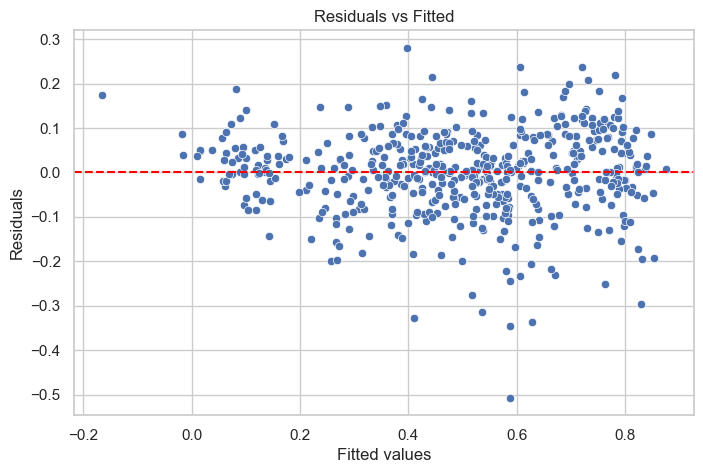

In [25]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_train_pred, y=residuals)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

The residuals are spread randomly around 0 with no clear pattern, no curve
and no funnel shape. So linearity and homoscedasticity (constant variance) look
fine.

### 9.2 Normality of residuals

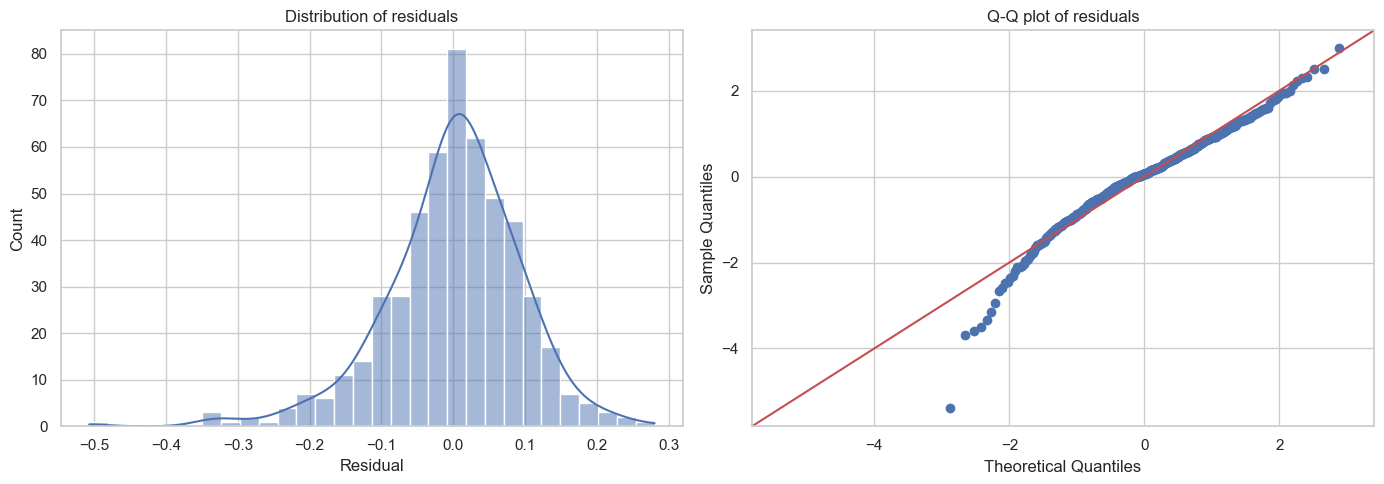

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(residuals, bins=30, kde=True, ax=axes[0])
axes[0].set_title("Distribution of residuals")
axes[0].set_xlabel("Residual")

sm.qqplot(residuals, line="45", fit=True, ax=axes[1])
axes[1].set_title("Q-Q plot of residuals")
plt.tight_layout()
plt.show()

The histogram is roughly bell shaped and most points on the Q-Q plot fall
on the 45 degree line. The tails deviate a little bit, but for a real-world
dataset this is acceptable. Residuals are approximately normal.

### 9.3 Multicollinearity check - VIF

In [27]:
vif_table(X_train[final_features])

,Feature,VIF
0,temp,7.733107
1,windspeed,5.148057
2,workingday,4.478432
3,season_winter,2.388484
4,yr,2.084955
5,season_spring,1.914155
6,mnth_nov,1.788366
7,weekday_sat,1.753786
8,weathersit_mist,1.580303
9,mnth_jul,1.456515


All VIFs are below 10, so no severe multicollinearity in the final model.

### 9.4 Independence of errors - Durbin-Watson

In [28]:
print(f"Durbin-Watson statistic: {sm.stats.stattools.durbin_watson(residuals):.3f}")

Durbin-Watson statistic: 2.059


A Durbin-Watson value close to 2 means the residuals are not auto-correlated,
so the independence assumption holds.

## 10. Predictions on the test set

In [29]:
X_test_const = sm.add_constant(X_test[final_features])
y_pred = final_model.predict(X_test_const)

train_r2 = r2_score(y_train, y_train_pred)
test_r2  = r2_score(y_test, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Train R²       : {train_r2:.4f}")
print(f"Train Adj-R²   : {final_model.rsquared_adj:.4f}")
print(f"Test  R²       : {test_r2:.4f}")
print(f"Test  RMSE     : {test_rmse:.4f}")

Train R²       : 0.8385
Train Adj-R²   : 0.8339
Test  R²       : 0.8274
Test  RMSE     : 0.0965


In [30]:
# Required snippet from the assignment
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.8274272862189456

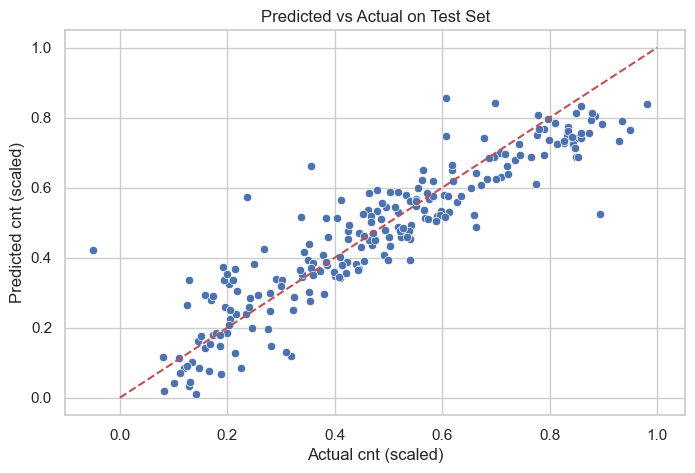

In [31]:
# Predicted vs Actual scatter
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([0, 1], [0, 1], "r--")
plt.xlabel("Actual cnt (scaled)")
plt.ylabel("Predicted cnt (scaled)")
plt.title("Predicted vs Actual on Test Set")
plt.show()

## 11. Reading the coefficients

In [32]:
coef = final_model.params.drop("const").sort_values(key=abs, ascending=False)
coef_df = pd.DataFrame({"Coefficient": coef})
coef_df

,Coefficient
temp,0.403936
weathersit_light_rain_snow,-0.278741
yr,0.241751
season_spring,-0.161634
windspeed,-0.091750
season_winter,0.087070
mnth_nov,-0.086464
weathersit_mist,-0.085645
mnth_dec,-0.068200
mnth_mar,0.055844


### 11.1 Final equation

```
cnt = 0.2100
      + 0.2418 * yr
      + 0.0476 * workingday
      + 0.4039 * temp
      - 0.0917 * windspeed
      - 0.1616 * season_spring
      + 0.0871 * season_winter
      - 0.2787 * weathersit_light_rain_snow
      - 0.0856 * weathersit_mist
      - 0.0682 * mnth_dec
      - 0.0498 * mnth_jul
      + 0.0558 * mnth_mar
      - 0.0865 * mnth_nov
      + 0.0496 * mnth_sep
      + 0.0553 * weekday_sat
```

Note: every numerical variable here is MinMax scaled to [0, 1], so the
coefficients are directly comparable in magnitude.

### 11.2 Top 3 features that drive the demand

Since everything is on the same [0, 1] scale, I can just look at the absolute
value of the coefficients:

1. **temp** (+0.404) - the biggest positive driver. Warmer days = more rentals.
2. **weathersit_light_rain_snow** (-0.279) - the biggest negative driver. Bad
   weather kills demand.
3. **yr** (+0.242) - 2019 demand is much higher than 2018. The platform is
   growing year on year.

## 12. Business takeaways

* Demand is mostly driven by temperature and weather. BoomBikes should make
  sure they have enough bikes available in fall, in the warmer months
  (roughly May to October) and on clear days.
* On rainy or snowy days demand drops sharply, so they can plan for fewer
  bikes or run discounts to push usage on those days.
* The positive `yr` coefficient confirms year on year growth - so investing
  in extra capacity post-lockdown is reasonable.
* Windspeed has a small negative effect, which is something to think about for
  windy seasons.

## 13. Conclusion

Final results from the model:

| Metric | Value |
|---|---|
| Train R-squared | 0.838 |
| Train Adjusted R-squared | 0.834 |
| Test R-squared | 0.827 |

Train and test R-squared are very close, so the model is not overfitting.
All 14 features in the final model have p-values < 0.05 and VIF < 10, so the
model is statistically clean and the coefficients can be trusted.